In [350]:
import pandas as pd
input_file = 'oracle_data_kb_elevations newww.csv'
df_row = pd.read_csv(input_file, header= 0)
print('Data Successfully Loaded')

Data Successfully Loaded


In [351]:
#remove rows where STATE_NAME is 'AK'
df_row = df_row[df_row['STATE_NAME'] != 'AK']
print('Rows where STATE_NAME is AK removed')
df_row.head()


Rows where STATE_NAME is AK removed


,BORE_ID,HEADER_ID,STATE_NAME,COUNTY_NAME,WELL_PROFILE_CODE,FIRST_ELEVATION,FIRST_ELEVATION_TYPE_CODE,FIRST_ELEVATION_SOURCE,SECOND_ELEVATION,SECOND_ELEVATION_TYPE_CODE,SECOND_ELEVATION_SOURCE,GROUND_ELEVATION,GROUND_ELEVATION_SOURCE,GROUND_ELEVATION_TYPE,KB HEIGHT,WELL_DATE,LATITUDE,LONGITUDE
2204,5532762,5446573,AL,BIBB,V,453.0,KB,ST_ALSOGB,NaN,NaN,NaN,447.0,ST_ALSOGB,GR,6,7/7/1990,33.096300,-87.006290
2205,5532771,5446580,AL,BIBB,V,510.0,KB,ST_ALSOGB,NaN,NaN,NaN,504.0,ST_ALSOGB,GR,6,7/29/1990,33.088490,-87.047960
2206,5532775,5446586,AL,BIBB,V,571.0,KB,ST_ALSOGB,NaN,NaN,NaN,565.0,ST_ALSOGB,GR,6,8/3/1990,33.085680,-87.041780
2207,5532829,5446641,AL,BIBB,V,366.0,KB,STATE,365.0,DF,STATE,360.0,ST_ALSOGB,GR,6,10/4/1990,33.112772,-87.058002
2208,5532836,5446647,AL,BIBB,V,370.0,KB,STATE,369.0,DF,STATE,364.0,ST_ALSOGB,GR,6,9/29/1990,33.105025,-87.057695


In [352]:
#remove rows where GROUND_ELEVATION_TYPE is 'GR' and GROUND_ELEVATION is 0
df_row = df_row[~((df_row['GROUND_ELEVATION_TYPE'] == 'GR') & (df_row['GROUND_ELEVATION'] == 0))]
#remove rows where KB HEIGHT > 50 or KB HEIGHT < 0
df_row = df_row[~((df_row['KB HEIGHT'] > 50) | (df_row['KB HEIGHT'] < 0))]
#remove rows where GROUND_ELEVATION_TYPE is 'EG' and GROUND_ELEVATION is 0
df_row = df_row[~((df_row['GROUND_ELEVATION_TYPE'] == 'EG') & (df_row['GROUND_ELEVATION'] == 0))]

print('Rows where GROUND_ELEVATION_TYPE is GR , EG and GROUND_ELEVATION is 0: and KB Hight > 50 or KB Hight < 0 removed')
df_row.head()







Rows where GROUND_ELEVATION_TYPE is GR , EG and GROUND_ELEVATION is 0: and KB Hight > 50 or KB Hight < 0 removed


,BORE_ID,HEADER_ID,STATE_NAME,COUNTY_NAME,WELL_PROFILE_CODE,FIRST_ELEVATION,FIRST_ELEVATION_TYPE_CODE,FIRST_ELEVATION_SOURCE,SECOND_ELEVATION,SECOND_ELEVATION_TYPE_CODE,SECOND_ELEVATION_SOURCE,GROUND_ELEVATION,GROUND_ELEVATION_SOURCE,GROUND_ELEVATION_TYPE,KB HEIGHT,WELL_DATE,LATITUDE,LONGITUDE
2204,5532762,5446573,AL,BIBB,V,453.0,KB,ST_ALSOGB,NaN,NaN,NaN,447.0,ST_ALSOGB,GR,6,7/7/1990,33.096300,-87.006290
2205,5532771,5446580,AL,BIBB,V,510.0,KB,ST_ALSOGB,NaN,NaN,NaN,504.0,ST_ALSOGB,GR,6,7/29/1990,33.088490,-87.047960
2206,5532775,5446586,AL,BIBB,V,571.0,KB,ST_ALSOGB,NaN,NaN,NaN,565.0,ST_ALSOGB,GR,6,8/3/1990,33.085680,-87.041780
2207,5532829,5446641,AL,BIBB,V,366.0,KB,STATE,365.0,DF,STATE,360.0,ST_ALSOGB,GR,6,10/4/1990,33.112772,-87.058002
2208,5532836,5446647,AL,BIBB,V,370.0,KB,STATE,369.0,DF,STATE,364.0,ST_ALSOGB,GR,6,9/29/1990,33.105025,-87.057695


In [353]:
#check missing value
missing_values = df_row.isnull().sum()
missing_percentage = (missing_values / len(df_row)) * 100

#create a dataframe to store missing values information
missing_info = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

print("Missing values information:")
print(missing_info)




Missing values information:
                            Missing Values  Percentage
BORE_ID                                  0    0.000000
HEADER_ID                                0    0.000000
STATE_NAME                               0    0.000000
COUNTY_NAME                              0    0.000000
WELL_PROFILE_CODE                        0    0.000000
FIRST_ELEVATION                          0    0.000000
FIRST_ELEVATION_TYPE_CODE                0    0.000000
FIRST_ELEVATION_SOURCE                   4    0.000883
SECOND_ELEVATION                    327591   72.300891
SECOND_ELEVATION_TYPE_CODE          327543   72.290297
SECOND_ELEVATION_SOURCE             327603   72.303540
GROUND_ELEVATION                         0    0.000000
GROUND_ELEVATION_SOURCE                  0    0.000000
GROUND_ELEVATION_TYPE                    0    0.000000
KB HEIGHT                                0    0.000000
WELL_DATE                                0    0.000000
LATITUDE                             

In [354]:
#remove columns with missing values more than 50%
df_row = df_row.dropna(axis=1, thresh=len(df_row) * 0.5)
print('Columns with missing values more than 50% removed')

#remove rows with missing values
df_row = df_row.dropna()
print('Rows with missing values removed')

Columns with missing values more than 50% removed
Rows with missing values removed


In [355]:
#check duplicate rows
duplicate_rows = df_row[df_row.duplicated()]
print(f'Number of duplicate rows: {len(duplicate_rows)}')


Number of duplicate rows: 0


In [ ]:
#remove the column {'BORE_ID' ,'HEADER_ID' ,'STATE_NAME' ,'COUNTY_NAME'}
df_row = df_row.drop(columns=['BORE_ID' ,'HEADER_ID' ,'STATE_NAME' ,'COUNTY_NAME','LATITUDE','LONGITUDE'])
print(df_row.head())



     WELL_PROFILE_CODE  FIRST_ELEVATION FIRST_ELEVATION_TYPE_CODE  \
2204                 V            453.0                        KB   
2205                 V            510.0                        KB   
2206                 V            571.0                        KB   
2207                 V            366.0                        KB   
2208                 V            370.0                        KB   

     FIRST_ELEVATION_SOURCE  GROUND_ELEVATION GROUND_ELEVATION_SOURCE  \
2204              ST_ALSOGB             447.0               ST_ALSOGB   
2205              ST_ALSOGB             504.0               ST_ALSOGB   
2206              ST_ALSOGB             565.0               ST_ALSOGB   
2207                  STATE             360.0               ST_ALSOGB   
2208                  STATE             364.0               ST_ALSOGB   

     GROUND_ELEVATION_TYPE  KB HEIGHT  WELL_DATE   LATITUDE  LONGITUDE  
2204                    GR          6   7/7/1990  33.096300 -87.006290  


In [357]:
from datetime import date
well_dt = pd.to_datetime(df_row['WELL_DATE'], format='mixed')
today = pd.Timestamp.now().normalize()
#create a new column 'WELL_AGE' and calculate the age of well using the 'WELL_DATE' column 
df_row['WELL_AGE'] = (today - well_dt).dt.days / 365
#drop the original 'WELL_DATE' column
df_row = df_row.drop(columns=['WELL_DATE'])
#round the 'WELL_AGE' column to integer
df_row['WELL_AGE'] = df_row['WELL_AGE'].round(0).astype(int)
#check the first few rows of the dataframe
print(df_row.head())


     WELL_PROFILE_CODE  FIRST_ELEVATION FIRST_ELEVATION_TYPE_CODE  \
2204                 V            453.0                        KB   
2205                 V            510.0                        KB   
2206                 V            571.0                        KB   
2207                 V            366.0                        KB   
2208                 V            370.0                        KB   

     FIRST_ELEVATION_SOURCE  GROUND_ELEVATION GROUND_ELEVATION_SOURCE  \
2204              ST_ALSOGB             447.0               ST_ALSOGB   
2205              ST_ALSOGB             504.0               ST_ALSOGB   
2206              ST_ALSOGB             565.0               ST_ALSOGB   
2207                  STATE             360.0               ST_ALSOGB   
2208                  STATE             364.0               ST_ALSOGB   

     GROUND_ELEVATION_TYPE  KB HEIGHT   LATITUDE  LONGITUDE  WELL_AGE  
2204                    GR          6  33.096300 -87.006290        36  
22

In [358]:
#need to see the unique value of each categorical feature
categorical_features = df_row.select_dtypes(include=['object']).columns
for feature in categorical_features:
    print(f'Unique values of {feature}: {df_row[feature].unique()}')


Unique values of WELL_PROFILE_CODE: ['V' 'D' 'H' 'U']
Unique values of FIRST_ELEVATION_TYPE_CODE: ['KB' 'DF']
Unique values of FIRST_ELEVATION_SOURCE: ['ST_ALSOGB' 'STATE' 'P2ES' 'UNKNOWN' 'P2_CALCFGD' 'COMP_RPT' 'ST_ARAOGC'
 'SCOUT' 'ST_CADOGGR' 'ST_AKOGCC' 'ST_ILDNR' 'ST_TXRRC' 'ST_AZOGCC'
 'C_C_RPT' 'C_LOG' 'FD_BLM' 'PERMIT' 'ST_TN' 'ST_LADNR' 'ST_NMOCD'
 'C_SURVEY' 'ST_COOGC' 'ST_ISGS' 'ST_OKOCC' 'ST_KYKGS' 'ST_KSKGS' 'ST_PA'
 'HIST' 'CLIENT' 'ST_UTOCD' 'ST_NEOGCC' 'DWS' 'ST_FL' 'ST_IAGS' 'ST_ID'
 'ST_IL' 'ST_INDNR' 'ST_INIGS' 'ST_MIDEQ' 'ST_MSOGB' 'ST_KYDNR'
 'FD_BOEMRE' 'ST_MO' 'ST_MTBOGC' 'ST_NDOGD' 'PLAT' 'ST_NVDMM' 'SUNDRY'
 'ST_WYOGCC' 'ST_OHDNR' 'ST_PADCNR' 'DONOTUSE' 'ST_OR' 'ST_PADEP'
 'ST_SDDENR' 'ST_TXGLO' 'FD_USGS' 'HPDI' 'ST_WA' 'ST_WVGS']
Unique values of GROUND_ELEVATION_SOURCE: ['ST_ALSOGB' 'STATE' 'FD_USGS' 'P2ES' 'COMP_RPT' 'UNKNOWN' 'ST_ARAOGC'
 'ST_CADOGGR' 'SCOUT' 'ST_TXRRC' 'ST_ISGS' 'ST_AKOGCC' 'ST_AZOGCC' 'C_LOG'
 'PERMIT' 'FD_BLM' 'ST_LADNR' 'ST_NMOCD' 'C_C

In [359]:
# Remove FIRST_ELEVATION_SOURCE ,GROUND_ELEVATION_SOURCE
df_row = df_row.drop(columns=['FIRST_ELEVATION_SOURCE', 'GROUND_ELEVATION_SOURCE','GROUND_ELEVATION_TYPE','FIRST_ELEVATION_TYPE_CODE'])

In [338]:
#check the categorical feature
categorical_features = df_row.select_dtypes(include=['object']).columns
print(categorical_features)

Index(['WELL_PROFILE_CODE'], dtype='object')


In [360]:
# Check for outliers in numerical columns using the IQR method
import numpy as np

numerical_features = df_row.select_dtypes(include=[np.number]).columns
outlier_summary = {}

for feature in numerical_features:
    Q1 = df_row[feature].quantile(0.25)
    Q3 = df_row[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_row[(df_row[feature] < lower_bound) | (df_row[feature] > upper_bound)]
    num_outliers = outliers.shape[0]
    if num_outliers > 0:
        print(f"Feature '{feature}': {num_outliers} outliers found.")
        outlier_summary[feature] = num_outliers
    else:
        print(f"Feature '{feature}': No outliers found.")

# If you want to view the actual outliers for a specific feature, you can do:
# print(df_row[(df_row['FEATURE_NAME'] < lower_bound) | (df_row['FEATURE_NAME'] > upper_bound)])

Feature 'FIRST_ELEVATION': 17503 outliers found.
Feature 'GROUND_ELEVATION': 17590 outliers found.
Feature 'KB HEIGHT': 6574 outliers found.
Feature 'LATITUDE': No outliers found.
Feature 'LONGITUDE': 118125 outliers found.
Feature 'WELL_AGE': 2011 outliers found.


In [340]:
#remoove the outliers except the KB HIGHT , LATTITUDE , LONGITUDE
# Remove outliers using IQR for all numerical features except 'KB HEIGHT', 'LATITUDE', 'LONGITUDE'
features_to_exclude = ['KB HEIGHT', 'LATITUDE', 'LONGITUDE']
numerical_features_to_check = [col for col in numerical_features if col not in features_to_exclude]

for feature in numerical_features_to_check:
    Q1 = df_row[feature].quantile(0.25)
    Q3 = df_row[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_row = df_row[(df_row[feature] >= lower_bound) & (df_row[feature] <= upper_bound)]

df_row = df_row.reset_index(drop=True)

In [341]:
# Use pandas get_dummies to convert categorical features to numerical (one-hot encoding)
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_array = encoder.fit_transform(df_row[categorical_features])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(categorical_features)
)

df_row = df_row.drop(columns=categorical_features)
df_row = pd.concat([df_row, encoded_df], axis=1)

print(df_row.head())

   FIRST_ELEVATION  GROUND_ELEVATION  KB HEIGHT   LATITUDE  LONGITUDE  \
0            453.0             447.0          6  33.096300 -87.006290   
1            510.0             504.0          6  33.088490 -87.047960   
2            571.0             565.0          6  33.085680 -87.041780   
3            366.0             360.0          6  33.112772 -87.058002   
4            370.0             364.0          6  33.105025 -87.057695   

   WELL_AGE  WELL_PROFILE_CODE_D  WELL_PROFILE_CODE_H  WELL_PROFILE_CODE_U  \
0        36                  0.0                  0.0                  0.0   
1        36                  0.0                  0.0                  0.0   
2        36                  0.0                  0.0                  0.0   
3        36                  0.0                  0.0                  0.0   
4        36                  0.0                  0.0                  0.0   

   WELL_PROFILE_CODE_V  
0                  1.0  
1                  1.0  
2                

In [342]:
# Get correlation values with 'KB HEIGHT'
correlations = df_row.corr(numeric_only=True)['KB HEIGHT'].sort_values(ascending=False)
print("Correlation of all features with 'KB HEIGHT':\n", correlations)

Correlation of all features with 'KB HEIGHT':
 KB HEIGHT              1.000000
WELL_PROFILE_CODE_H    0.579942
WELL_PROFILE_CODE_D    0.020379
FIRST_ELEVATION        0.006343
GROUND_ELEVATION       0.001153
WELL_PROFILE_CODE_U   -0.005864
LONGITUDE             -0.111687
LATITUDE              -0.126473
WELL_AGE              -0.399249
WELL_PROFILE_CODE_V   -0.533479
Name: KB HEIGHT, dtype: float64


In [343]:
# Use statsmodels to evaluate the significance of features for predicting 'KB HEIGHT'
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# Set up target and features for regression (excluding 'KB HEIGHT' itself)
X = df_row.drop(['KB HEIGHT'], axis=1)
y = df_row['KB HEIGHT']

# Add constant for intercept
#X_with_const = sm.add_constant(X)
# Standardize the data before applying PCA
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Fit OLS regression model
model = sm.OLS(y, X)
results = model.fit()

# Summarize results
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:              KB HEIGHT   R-squared (uncentered):                   0.196
Model:                            OLS   Adj. R-squared (uncentered):              0.196
Method:                 Least Squares   F-statistic:                          1.311e+04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):                        0.00
Time:                        09:33:35   Log-Likelihood:                     -1.7927e+06
No. Observations:              430460   AIC:                                  3.586e+06
Df Residuals:                  430452   BIC:                                  3.586e+06
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [344]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

# Set up target and features for regression (excluding 'KB HEIGHT' itself)
X = df_row.drop(['KB HEIGHT'], axis=1)
y = df_row['KB HEIGHT']

# Add constant for intercept
#X = sm.add_constant(X)
# Standardize the data before applying PCA
scaler = StandardScaler()
X = scaler.fit_transform(X)

models = {
    "Linear Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    
    "Ridge Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    
    "Lasso Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]),
    
    #"Random Forest": RandomForestRegressor(
    #    n_estimators=200,
    #    max_depth=10,
    #    random_state=42
    #),
    
    #"Gradient Boosting": GradientBoostingRegressor(
    #    n_estimators=200,
    #    learning_rate=0.05,
    #    max_depth=3,
    #    random_state=42
    #)
}

# -----------------------------
# K-Fold
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# Scoring
# -----------------------------
scoring = {
    'MSE': make_scorer(mean_squared_error),
    'MAE': make_scorer(mean_absolute_error),
    'R2': make_scorer(r2_score)
}

results = {}

# -----------------------------
# Evaluation
# -----------------------------
for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    print(f"\n{name} - Per Fold Results")
    for i in range(len(scores['test_R2'])):
        print(
            f"Fold {i+1}: "
            f"MSE={scores['test_MSE'][i]:.4f}, "
            f"MAE={scores['test_MAE'][i]:.4f}, "
            f"R2={scores['test_R2'][i]:.4f}"
        )

    results[name] = {
        'MSE': scores['test_MSE'].mean(),
        'MAE': scores['test_MAE'].mean(),
        'R2': scores['test_R2'].mean()
    }
# -----------------------------
# Results
# -----------------------------
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='R2', ascending=False)

print(results_df)

best_model = results_df.index[0]
print(f"\n✅ Best Model Based on R2: {best_model}")



Linear Regression - Per Fold Results
Fold 1: MSE=0.0167, MAE=0.0529, R2=0.9997
Fold 2: MSE=0.0167, MAE=0.0530, R2=0.9997
Fold 3: MSE=0.0169, MAE=0.0535, R2=0.9997
Fold 4: MSE=0.0165, MAE=0.0525, R2=0.9997
Fold 5: MSE=0.0168, MAE=0.0529, R2=0.9997

Ridge Regression - Per Fold Results
Fold 1: MSE=2.4320, MAE=1.0429, R2=0.9589
Fold 2: MSE=2.4772, MAE=1.0573, R2=0.9581
Fold 3: MSE=2.5154, MAE=1.0623, R2=0.9579
Fold 4: MSE=2.4066, MAE=1.0423, R2=0.9590
Fold 5: MSE=2.4518, MAE=1.0535, R2=0.9584

Lasso Regression - Per Fold Results
Fold 1: MSE=36.2029, MAE=4.0213, R2=0.3879
Fold 2: MSE=36.4818, MAE=4.0579, R2=0.3833
Fold 3: MSE=37.0038, MAE=4.0723, R2=0.3806
Fold 4: MSE=35.8058, MAE=4.0217, R2=0.3897
Fold 5: MSE=36.2128, MAE=4.0476, R2=0.3848
                         MSE       MAE        R2
Linear Regression   0.016715  0.052957  0.999717
Ridge Regression    2.456597  1.051664  0.958445
Lasso Regression   36.341395  4.044160  0.385251

✅ Best Model Based on R2: Linear Regression


In [345]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

r2_scores = cross_val_score(
    linear_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Fold R2 scores:", r2_scores)
print("Mean R2:", r2_scores.mean())
print("Std Dev:", r2_scores.std())


Fold R2 scores: [0.99941961 0.99975353 0.99985188 0.99923526 0.99950051]
Mean R2: 0.9995521583796613
Std Dev: 0.0002240726342227557


In [346]:
from sklearn.model_selection import train_test_split

# Split the dataset into train and test sets (80% train, 20% test for example)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the Ridge model on training data
#ridge_model.fit(X_train, y_train)

# Fit the Linear Regression model on training data
linear_model.fit(X_train, y_train)

# Predict KB Height on the test set
y_pred = linear_model.predict(X_test)


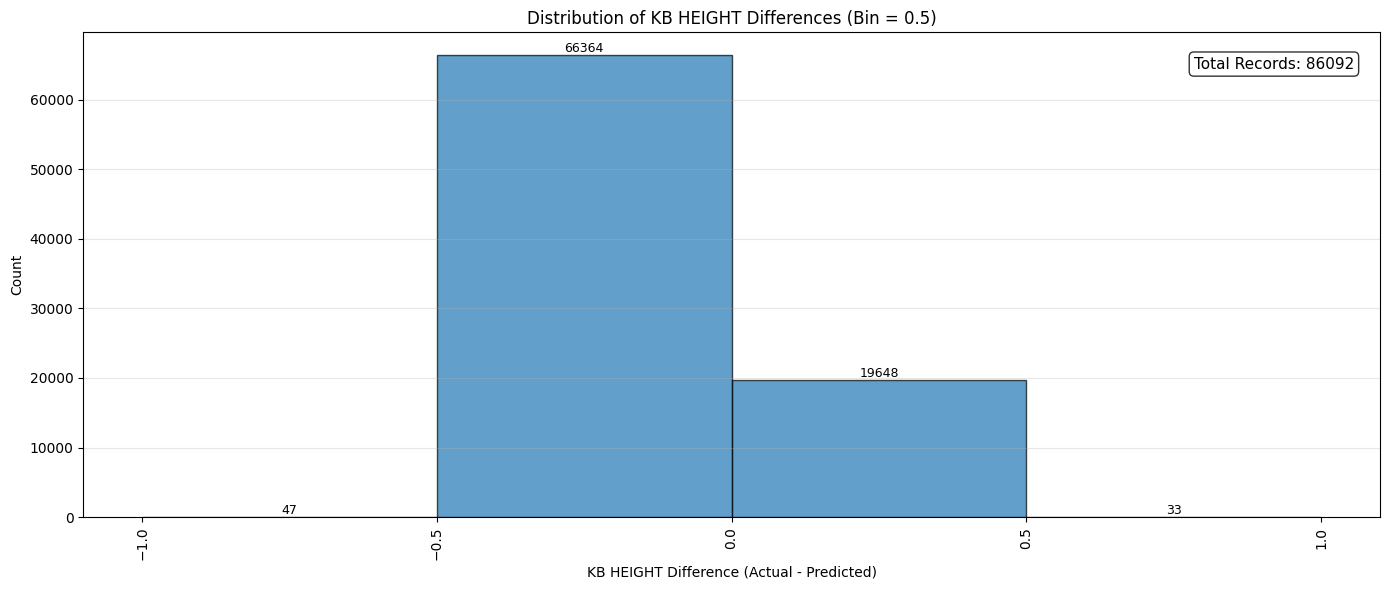

In [347]:
import matplotlib.pyplot as plt
import numpy as np

# Difference between actual and predicted
kb_height_diff = y_test - y_pred

# Bin width
bin_width = 0.5

# Create aligned bins
min_edge = bin_width * np.floor(kb_height_diff.min() / bin_width)
max_edge = bin_width * np.ceil(kb_height_diff.max() / bin_width)
bin_edges = np.arange(min_edge, max_edge + bin_width, bin_width)

plt.figure(figsize=(14, 6))

# Histogram
counts, bins, patches = plt.hist(
    kb_height_diff,
    bins=bin_edges,
    edgecolor='black',
    alpha=0.7
)

# Label counts on bars
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            int(count),
            ha='center',
            va='bottom',
            fontsize=9
        )

# Labels
plt.xlabel('KB HEIGHT Difference (Actual - Predicted)')
plt.ylabel('Count')
plt.title('Distribution of KB HEIGHT Differences (Bin = 0.5)')

plt.xticks(bin_edges, rotation=90)
plt.grid(axis='y', alpha=0.3)

# 👉 Total record count annotation
total_records = len(kb_height_diff)
plt.text(
    0.98, 0.95,
    f'Total Records: {total_records}',
    transform=plt.gca().transAxes,
    ha='right',
    va='top',
    fontsize=11,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()


In [348]:
import pandas as pd
import numpy as np

# Absolute error
abs_error = np.abs(y_test - y_pred)
bins = [0, 2, 4, 6, 10, np.inf]
labels = ['0-2', '2-4', '4-6', '6-10', '10+']
error_distribution = pd.cut(
    abs_error,
    bins=bins,
    labels=labels,
    right=False
)

summary_df = (
    error_distribution
    .value_counts()
    .sort_index()
    .reset_index()
)

summary_df.columns = ['Error Range', 'Count']

# Add percentage
summary_df['Percentage (%)'] = (
    summary_df['Count'] / summary_df['Count'].sum() * 100
).round(2)

summary_df


,Error Range,Count,Percentage (%)
0,0-2,86092,100.0
1,2-4,0,0.0
2,4-6,0,0.0
3,6-10,0,0.0
4,10+,0,0.0


In [349]:
import numpy as np

# X_test is a numpy array (no .index), but y_test is a pandas Series and retains its index
df_row_test = df_row.loc[y_test.index].copy()

df_row_test['KB_HEIGHT_ACTUAL'] = y_test.values
df_row_test['KB_HEIGHT_PREDICTED'] = np.asarray(y_pred).ravel()

df_row_test.to_csv('kb_height_actual_vs_predicted.csv', index=False)
print(f'Saved {len(df_row_test)} rows to kb_height_actual_vs_predicted.csv')


Saved 86092 rows to kb_height_actual_vs_predicted.csv


In [325]:
import joblib

# Save the trained model
joblib.dump(linear_model, "KB_missing_hight_prediction_model.pkl")

['KB_missing_hight_prediction_model.pkl']

In [326]:
#Save preprocessing too
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [327]:

joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']